In [37]:
import pickle
import spike.spike_analysis.population_analysis as pcat
import spike.spike_analysis.firing_rate_calculations as fr
import spike.spike_analysis.spike_collection as sc
import spike.spike_analysis.spike_recording as recording
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.stats import sem
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ttest_rel
import matplotlib.patches as mpatches
from itertools import combinations
from matplotlib.patches import Patch
import matplotlib.ticker as ticker
import seaborn as sns
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['figure.titleweight'] = 'bold'

def hex_2_rgb(hex_color): # Orange color
    rgb_color = tuple(int(hex_color[i:i+2], 16) / 255.0 for i in (1, 3, 5))
    return rgb_color

def pickle_this(thing_to_pickle, file_name):
    """
    Pickles things
    Args (2):   
        thing_to_pickle: anything you want to pickle
        file_name: str, filename that ends with .pkl 
    Returns:
        none
    """
    with open(file_name,'wb') as file:
        pickle.dump(thing_to_pickle, file)

def unpickle_this(pickle_file):
    """
    Unpickles things
    Args (1):   
        file_name: str, pickle filename that already exists and ends with .pkl
    Returns:
        pickled item
    """
    with open(pickle_file, 'rb') as file:
        return(pickle.load(file))
    


In [38]:
TIMEBIN = 100
IGNORE_FREQ = 0.5
SMOOTHING_WINDOW = 500
only_subjects_spike = sc.SpikeCollection.load_collection(r"C:\Users\megha\UF Dropbox\Meghan Cum\Padilla-Coreano Lab\2024\Cum_SocialMemEphys_pilot2\only_subjects_spike_collection\spike_collection.json")
only_subjects_spike.analyze(timebin = TIMEBIN, ignore_freq=IGNORE_FREQ, smoothing_window=SMOOTHING_WINDOW)



All set to analyze


# Basic PCA PLotting

In [3]:

def plot_pca_results_3d(pca_result, title, colors, azim, elev, save = False):
    event_lengths = int(
            (pca_result.event_length + pca_result.pre_window + pca_result.post_window) * 1000 / pca_result.timebin
        )
    
    event_end = int((pca_result.event_length + pca_result.pre_window) * 1000 / pca_result.timebin)
    pre_window = pca_result.pre_window * 1000 / pca_result.timebin
    post_window = pca_result.post_window * 1000 / pca_result.timebin
    pc_var = pca_result.explained_variance
    PCA_key = pca_result.labels
    PCA_matrix = pca_result.transformed_data
    col_counter = 0
    fig = plt.figure(figsize = (8,8))
    ax = fig.add_subplot(111, projection="3d")
    #plt.subplots_adjust(left=0.3, right=0.99, bottom=0.1, top=0.9)
    for i in range(0, len(PCA_key), event_lengths):
        event_label = PCA_key[i]
        onset = int(i + pre_window - 1)
        end = int(i + event_end - 1)
        post = int(i + event_lengths - 1)
        ax.plot3D(
            PCA_matrix[i : i + event_lengths, 0],
            PCA_matrix[i : i + event_lengths, 1],
            PCA_matrix[i : i + event_lengths, 2],
            label=event_label,
            color=colors[col_counter],
            linewidth = 5,
            alpha = 0.8
        )
        ax.scatter(
            PCA_matrix[i, 0],
            PCA_matrix[i, 1],
            PCA_matrix[i, 2],
            marker="s",
            s=100,
            c="w",
            edgecolors=colors[col_counter],
        )
        ax.scatter(
            PCA_matrix[onset, 0],
            PCA_matrix[onset, 1],
            PCA_matrix[onset, 2],
            marker="^",
            s=300,
            c="w",
            edgecolors=colors[col_counter],
        )
        ax.scatter(
            PCA_matrix[end, 0],
            PCA_matrix[end, 1],
            PCA_matrix[end, 2],
            marker="o",
            s=200,
            c="w",
            edgecolors=colors[col_counter],
        )
        if post_window != 0:
            ax.scatter(
                PCA_matrix[post, 0],
                PCA_matrix[post, 1],
                PCA_matrix[post, 2],
                marker="D",
                s=200,
                c="w",
                edgecolors=colors[col_counter],
            )
        col_counter += 1
    ax.legend(loc="upper left", bbox_to_anchor=(.9,1), frameon = False, fontsize = 14)
    # ax.set_xlim(-20, 45)
    # ax.set_ylim(-5, 25)
    # ax.set_zlim(-20, 30)
    ax.view_init(azim = azim, elev =elev)
    ax.set_title(f"{title}", fontsize = 24, y = 1)
    ax.set_xlabel(f"PC1 ({pc_var[0]*100:.1f}% variance)", fontsize = 16, labelpad = -10)
    ax.set_ylabel(f"PC2 ({pc_var[1]*100:.1f}% variance)", fontsize = 16, labelpad = -10)
    ax.set_zlabel(f"PC3 ({pc_var[2]*100:.1f}% variance)", fontsize = 16, labelpad = -10)
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.set_zticklabels([])
    ax.yaxis.pane.set_alpha(0.9)
    ax.xaxis.pane.set_alpha(0.9)
    ax.zaxis.pane.set_alpha(0.9)
    plt.tight_layout()
    if save:
        plt.savefig(f'{title}.png', dpi = 600, transparent = True,bbox_inches='tight' )
    plt.show()


def plot_pca_results_2d(pca_result, title, colors, legend_spot, save=False):
    event_lengths = int(
        (pca_result.event_length + pca_result.pre_window + pca_result.post_window) * 1000 / pca_result.timebin
    )
    
    event_end = int((pca_result.event_length + pca_result.pre_window) * 1000 / pca_result.timebin)
    pre_window = pca_result.pre_window * 1000 / pca_result.timebin
    post_window = pca_result.post_window * 1000 / pca_result.timebin
    pc_var = pca_result.explained_variance
    PCA_key = pca_result.labels
    PCA_matrix = pca_result.transformed_data
    col_counter = 0
    
    # Create figure with updated size
    fig = plt.figure(figsize=(6, 6))
    ax = fig.add_subplot(111)
    
    for i in range(0, len(PCA_key), event_lengths):
        event_label = PCA_key[i]
        onset = int(i + pre_window - 1)
        end = int(i + event_end - 1)
        post = int(i + event_lengths - 1)
        
        # Plot the continuous line with updated styling
        ax.plot(
            PCA_matrix[i:i + event_lengths, 0],
            PCA_matrix[i:i + event_lengths, 1],
            label=event_label,
            color=colors[col_counter],
            linewidth=5,
            alpha=0.8,
            zorder = 1
        )
        
        # Add markers with updated sizes
        ax.scatter(
            PCA_matrix[i, 0],
            PCA_matrix[i, 1],
            marker="s",
            s=200,
            c="w",
            edgecolors=colors[col_counter],
            zorder = 2
        )
        ax.scatter(
            PCA_matrix[onset, 0],
            PCA_matrix[onset, 1],
            marker="^",
            s=300,
            c="w",
            edgecolors=colors[col_counter],
            zorder = 3
        )
        ax.scatter(
            PCA_matrix[end, 0],
            PCA_matrix[end, 1],
            marker="o",
            s=200,
            c="w",
            edgecolors=colors[col_counter],
            zorder = 4
        )
        if post_window != 0:
            ax.scatter(
                PCA_matrix[post, 0],
                PCA_matrix[post, 1],
                marker="D",
                s=200,
                c="w",
                edgecolors=colors[col_counter],
                zorder =5
            )
        col_counter += 1
    
    # Updated legend formatting
    ax.legend(loc="upper left", bbox_to_anchor=legend_spot, frameon=False, fontsize=14)
    
    # ax.set_xlim(-20, 45)
    # ax.set_ylim(-5, 25)
    
    # Updated title and label formatting
    ax.set_title(f"{title}", fontsize=24, y=1.01)
    ax.set_xlabel(f"PC1 ({pc_var[0]*100:.1f}% variance)", fontsize=16)
    ax.set_ylabel(f"PC2 ({pc_var[1]*100:.1f}% variance)", fontsize=16)
    
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.set_yticks([])
    ax.set_xticks([])
    
    # Add tight layout
    plt.tight_layout()
    
    if save:
        plt.savefig(f'{title}.png', dpi=600, transparent=True, bbox_inches='tight')
    plt.show()

Excluding 22_NCF_merged.rec with 1 neurons
Excluding 23_CNF_merged.rec with 3 neurons
Excluding 23_NFC_merged.rec with 2 neurons


c:\Users\megha\anaconda3\envs\ephys_env\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(
c:\Users\megha\anaconda3\envs\ephys_env\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(
C:\Users\megha\AppData\Local\Temp\ipykernel_34964\677874798.py:83: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


Excluding 22_NCF_merged.rec with 1 neurons
Excluding 23_CNF_merged.rec with 3 neurons
Excluding 23_NFC_merged.rec with 2 neurons


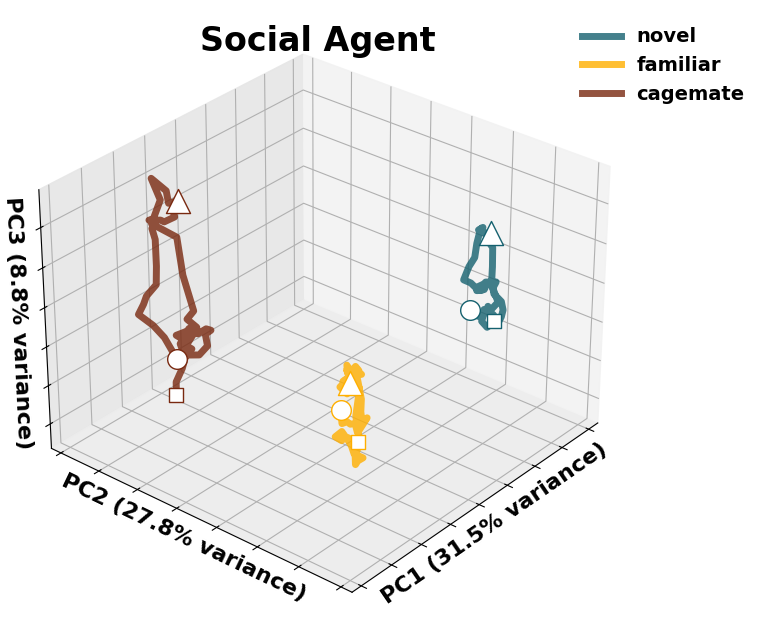

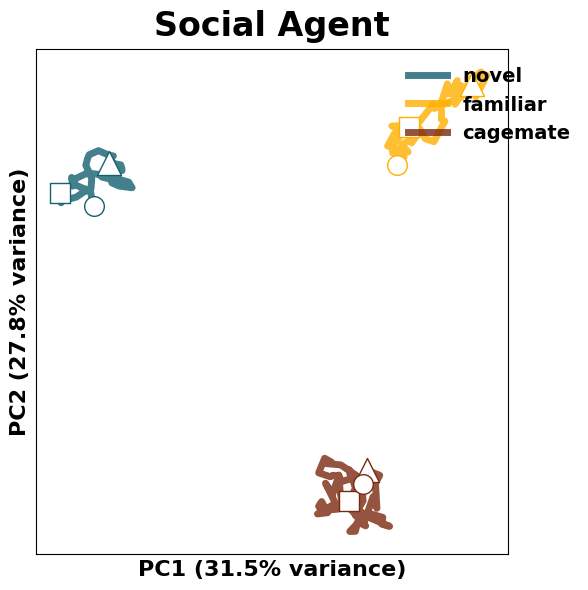

PCA Result with:
Events: novel, familiar, cagemate
Timebins per event: 50.0
Total neurons: 150
Number of recordings: 12
Number of Pcs needed to explain 90% of variance 12


In [4]:

agent_pca_results = pcat.avg_trajectories_pca(only_subjects_spike, 3, 2, events = ['novel', 'familiar', 'cagemate'], min_neurons=5, plot = False)
order_pca_results = pcat.avg_trajectories_pca(only_subjects_spike, 3, 2, events = ['exposure_1', 'exposure_2', 'exposure_3'],min_neurons=5, plot = False)

exp_colors = [hex_2_rgb('#bc9488'),
              hex_2_rgb('#9b5f4c'),
              hex_2_rgb('#792910')]
agent_colors = ['#15616F',
                '#FFAF00',
                '#792910']
plot_pca_results_3d(agent_pca_results, "Social Agent", agent_colors, azim = 40, elev = 30)
plot_pca_results_2d(agent_pca_results, "Social Agent", colors = agent_colors, legend_spot = (0.75, 1))

print(agent_pca_results)

C:\Users\megha\AppData\Local\Temp\ipykernel_34964\677874798.py:83: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


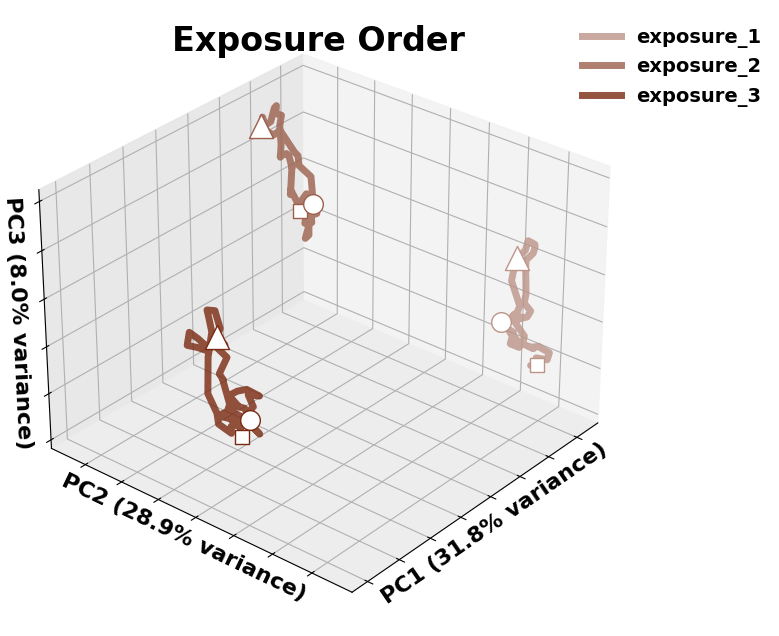

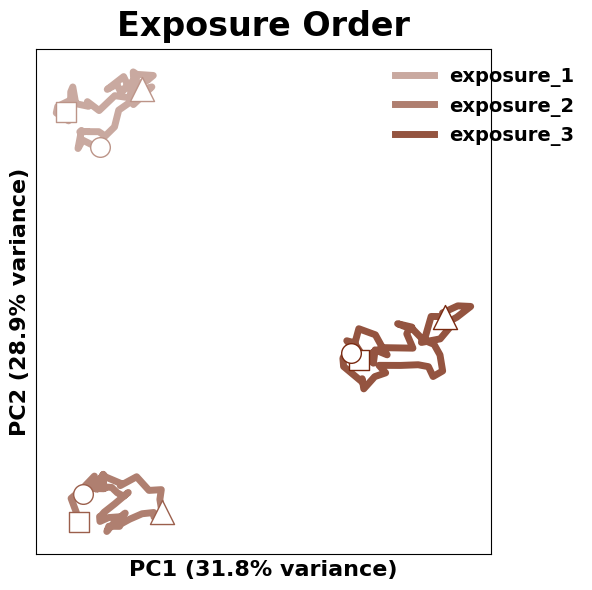

PCA Result with:
Events: exposure_1, exposure_2, exposure_3
Timebins per event: 50.0
Total neurons: 150
Number of recordings: 12
Number of Pcs needed to explain 90% of variance 12


In [5]:
plot_pca_results_3d(order_pca_results, "Exposure Order", exp_colors, azim = 40, elev = 30)
plot_pca_results_2d(order_pca_results, "Exposure Order", colors = exp_colors, legend_spot = (0.75, 1))
print(order_pca_results)


## Distance plotting

In [12]:
geo_dist_agent = pcat.average_trajectory_distances(only_subjects_spike, 3, 2, post_window=0, min_neurons = 5, events = ['cagemate', 'familiar', 'novel'], weighted=True)
geo_dist_agent
geo_dist_order = pcat.average_trajectory_distances(only_subjects_spike, 3, 2, post_window=0, min_neurons = 5, events = ['exposure_1', 'exposure_2', 'exposure_3'], weighted=True)
geo_dist_order

Excluding 22_NCF_merged.rec with 1 neurons
Excluding 23_CNF_merged.rec with 3 neurons
Excluding 23_NFC_merged.rec with 2 neurons
Excluding 22_NCF_merged.rec with 1 neurons
Excluding 23_CNF_merged.rec with 3 neurons
Excluding 23_NFC_merged.rec with 2 neurons


,exposure_1_exposure_2,exposure_1_exposure_3,exposure_2_exposure_3
11_CNF_merged.rec,13.033810,9.676105,11.277770
11_NCF_merged.rec,19.916086,15.835055,15.666214
12_CNF_merged.rec,12.960808,17.246407,14.167599
13_NCF_merged.rec,14.276722,19.875580,23.845167
21_FCN_merged.rec,16.990612,29.886261,18.213222
21_NCF_merged.rec,40.614261,30.329466,25.815132
22_FCN_merged.rec,23.719419,25.541182,24.073574
24_CNF_merged.rec,31.295838,19.750442,27.180159
24_NFC_merged.rec,26.072241,39.155122,32.275090
32_NFC_merged.rec,19.919922,21.742949,22.611489


In [13]:
geo_dist_order.columns = ['exp1_exp2', 'exp1_exp3', 'exp2_exp3']
geo_dist_order

,exp1_exp2,exp1_exp3,exp2_exp3
11_CNF_merged.rec,13.033810,9.676105,11.277770
11_NCF_merged.rec,19.916086,15.835055,15.666214
12_CNF_merged.rec,12.960808,17.246407,14.167599
13_NCF_merged.rec,14.276722,19.875580,23.845167
21_FCN_merged.rec,16.990612,29.886261,18.213222
21_NCF_merged.rec,40.614261,30.329466,25.815132
22_FCN_merged.rec,23.719419,25.541182,24.073574
24_CNF_merged.rec,31.295838,19.750442,27.180159
24_NFC_merged.rec,26.072241,39.155122,32.275090
32_NFC_merged.rec,19.919922,21.742949,22.611489


In [14]:
from matplotlib.colors import LinearSegmentedColormap
def create_comparison_matrix(df):
    # Get unique experiments
    experiments = sorted(list(set([exp for col in df.columns for exp in col.split('_')])))
    n = len(experiments)
    
    # Create empty matrix
    matrix = np.zeros((n, n))
    
    # Fill matrix
    for i, exp1 in enumerate(experiments):
        for j, exp2 in enumerate(experiments):
            if i == j:
                matrix[i,j] = 1
            else:
                col1 = f"{exp1}_{exp2}"
                col2 = f"{exp2}_{exp1}"
                if col1 in df.columns:
                    matrix[i,j] = df[col1].mean()
                elif col2 in df.columns:
                    matrix[i,j] = df[col2].mean()
    
    return pd.DataFrame(matrix, index=experiments, columns=experiments)

def plot_comparison_heatmap(df, title, color, diagonal_color, vmin):
    # Create comparison matrix
    matrix = create_comparison_matrix(df)
    
    # Create figure
    plt.figure(figsize=(5, 4))
    n_bins = 100  # Number of color gradients
    cmap = LinearSegmentedColormap.from_list('custom', color, N=n_bins)
    # Create heatmap
    sns.heatmap(matrix, 
                annot=True, 
                cmap=cmap,
                fmt='.0f',
                square=True,
                cbar_kws={'label': 'AU Distance'},
                vmin = vmin)
    for i in range(len(matrix)):
        plt.plot(i + 0.5, i + 0.5, 'o', color=diagonal_color, markersize=25, zorder =100)
    
    plt.title(title, fontsize = 16)
    plt.tight_layout()
    return plt



<module 'matplotlib.pyplot' from 'c:\\Users\\megha\\anaconda3\\envs\\ephys_env\\lib\\site-packages\\matplotlib\\pyplot.py'>

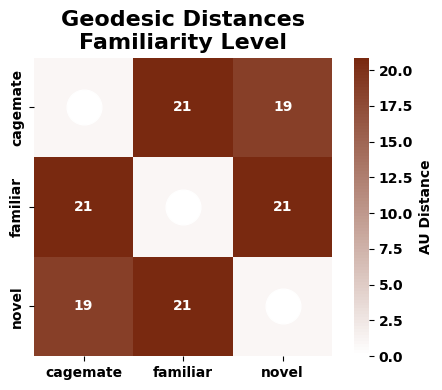

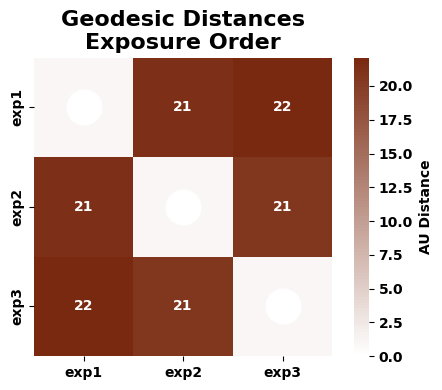

In [15]:
plot_comparison_heatmap(geo_dist_agent, title = "Geodesic Distances\nFamiliarity Level", color = ['white', '#792910'], diagonal_color='white', vmin = 0)
plot_comparison_heatmap(geo_dist_order, title = "Geodesic Distances\nExposure Order", color = ['white', '#792910'], diagonal_color='white', vmin = 0)

## Trajectroy Lenght Plotting 

In [18]:
traj_lengths = pcat.avg_traj_len(only_subjects_spike, 3, 2, post_window=0, min_neurons = 5, events = ['cagemate', 'familiar', 'novel'])

Excluding 22_NCF_merged.rec with 1 neurons
Excluding 23_CNF_merged.rec with 3 neurons
Excluding 23_NFC_merged.rec with 2 neurons


In [19]:
geo_dist_agent['cage_dist'] = geo_dist_agent['cagemate_familiar'] - geo_dist_agent['cagemate_novel']
geo_dist_agent['familiar_dist'] = geo_dist_agent['cagemate_familiar'] - geo_dist_agent['familiar_novel']
geo_dist_agent['novel_dist'] = geo_dist_agent['cagemate_novel'] - geo_dist_agent['familiar_novel']
geo_dist_agent

,cagemate_familiar,cagemate_novel,familiar_novel,cage_dist,familiar_dist,novel_dist
11_CNF_merged.rec,13.902247,9.888674,13.370484,4.013573,0.531763,-3.481810
11_NCF_merged.rec,14.763389,25.418350,30.628882,-10.654962,-15.865494,-5.210532
12_CNF_merged.rec,18.412555,11.146276,19.837163,7.266279,-1.424608,-8.690887
13_NCF_merged.rec,24.493675,20.327341,16.966587,4.166333,7.527088,3.360754
21_FCN_merged.rec,19.496193,14.196627,22.798884,5.299566,-3.302691,-8.602256
21_NCF_merged.rec,30.511732,22.679683,32.225366,7.832049,-1.713634,-9.545683
22_FCN_merged.rec,25.535132,22.996540,15.844254,2.538592,9.690878,7.152286
24_CNF_merged.rec,22.840524,23.185767,20.484673,-0.345242,2.355852,2.701094
24_NFC_merged.rec,26.725904,25.153230,19.823533,1.572674,6.902371,5.329697
32_NFC_merged.rec,16.334342,18.822932,19.782510,-2.488590,-3.448168,-0.959578


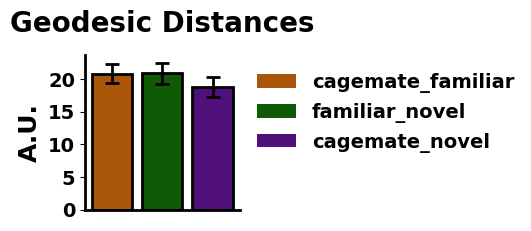

,Comparison,t_statistic,p_value,p_adjusted,significant
0,Nov_Fam,-0.034159,0.973362,0.973362,False
1,Nov_cage,1.423745,0.182262,0.546787,False
2,fam_Cage,1.288898,0.223880,0.546787,False


In [20]:
from scipy.spatial.distance import euclidean
from statsmodels.stats.multitest import multipletests

geo_distances = np.array([geo_dist_agent['cagemate_familiar'].values, geo_dist_agent['familiar_novel'].values, geo_dist_agent['cagemate_novel'].values]).T
geo_distances.shape


means = np.mean(geo_distances, axis = 0)
sems = sem(geo_distances, axis = 0)

agent_colors = ['#15616F',
                '#FFAF00',
                '#792910']
t_nf, p_nf = stats.ttest_rel(geo_distances[:,0], geo_distances[:,1])
t_nc, p_nc = stats.ttest_rel(geo_distances[:,0], geo_distances[:,2])
t_fc, p_fc = stats.ttest_rel(geo_distances[:,1], geo_distances[:,2])
p_values = [p_nf, p_nc, p_fc]
reject, p_adjusted, _, _ = multipletests(p_values, method='holm')
stats_df = pd.DataFrame({
   'Comparison': ['Nov_Fam', 'Nov_cage', 'fam_Cage'],
   't_statistic': [t_nf, t_nc, t_fc],
   'p_value': p_values,
   'p_adjusted': p_adjusted,
   'significant': reject
})


color_id_dict = {'cagemate_familiar': "#AA570A", 
                'familiar_novel': "#0F5A05",
                'cagemate_novel': "#4F1079"}
hatches = ['','','']  
x = [0.5,1,1.5]
plt.figure(figsize= (2,2))           
plt.bar(x, means, yerr = sems,
            color = color_id_dict.values(), hatch = hatches,
            edgecolor = ['black', 'black', 'black'],
            capsize = 5, linewidth = 2,
            error_kw={'elinewidth': 2, 'capthick': 2}, 
            width = .4)
plt.xticks([],rotation=45)
legend_handles = [Patch(facecolor=color, label=label) for label, color in color_id_dict.items()]
plt.legend(handles=legend_handles,
           bbox_to_anchor=(1,1),
           frameon= False, fontsize = 14)
plt.ylabel('A.U.', fontsize = 18)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
# plt.gca().yaxis.set_major_locator(ticker.MultipleLocator(300))
# plt.ylim(500,1500)
plt.gca().spines['bottom'].set_linewidth(2)  # X-axis
plt.gca().spines['left'].set_linewidth(2) 
plt.title('Geodesic Distances', fontsize = 20, y = 1.1)
plt.show()
stats_df

# Decoder analyses

In [22]:
import spike.spike_analysis.decoders as decoders 
num_fold = 5
event_length = 3
pre_window = 2
post_window = 0
min_neurons = 5


agent_results = decoders.trial_decoder(only_subjects_spike,
                                              num_fold = num_fold,
                                            
                                              events = ['novel', 'familiar', 'cagemate'],
                                              event_length = event_length,
                                              pre_window = pre_window,
                                              post_window = post_window,
                                              min_neurons = min_neurons,
                                              classifier_type = 'linear',
                                              plot = False)


agent_results_shuffle = decoders.trial_decoder_within_subject_shuffle(only_subjects_spike,
                                              num_fold = num_fold,
                                            
                                              events = ['novel', 'familiar', 'cagemate'],
                                              event_length = event_length,
                                              pre_window = pre_window,
                                              post_window = post_window,
                                              min_neurons = min_neurons,
                                              classifier_type = 'linear',
                                              plot = False)
order_results = decoders.trial_decoder(only_subjects_spike,
                                              num_fold = num_fold,
                                             
                                              events = ['exposure_1', 'exposure_2', 'exposure_3'],
                                              event_length = event_length,
                                              pre_window = pre_window,
                                              post_window = post_window,
                                              min_neurons = min_neurons,
                                              classifier_type='linear',
                                              plot = False)

Excluding 22_NCF_merged.rec with 1 neurons
Excluding 23_CNF_merged.rec with 3 neurons
Excluding 23_NFC_merged.rec with 2 neurons


c:\Users\megha\anaconda3\envs\ephys_env\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


Excluding 22_NCF_merged.rec with 1 neurons
Excluding 23_CNF_merged.rec with 3 neurons
Excluding 23_NFC_merged.rec with 2 neurons


c:\Users\megha\anaconda3\envs\ephys_env\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


Excluding 22_NCF_merged.rec with 1 neurons
Excluding 23_CNF_merged.rec with 3 neurons
Excluding 23_NFC_merged.rec with 2 neurons


c:\Users\megha\anaconda3\envs\ephys_env\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


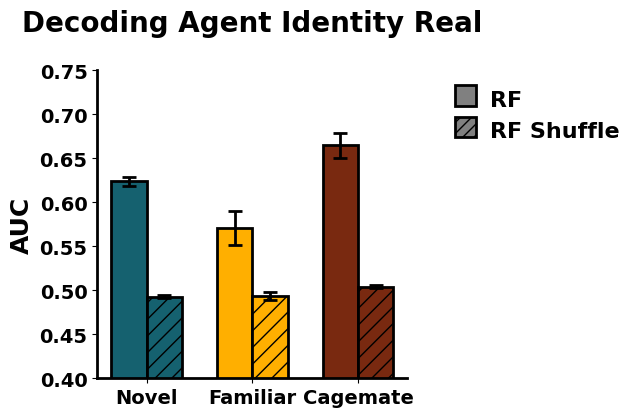

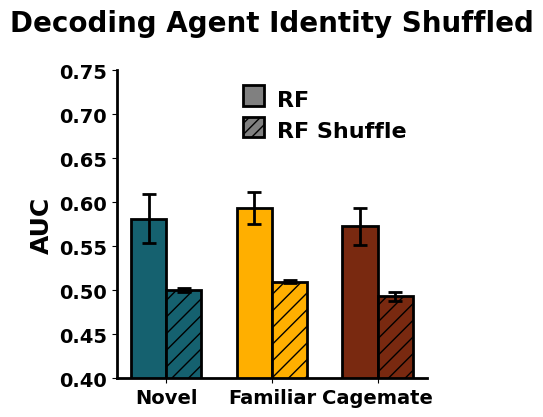

In [23]:
from matplotlib.patches import Patch
def plot_multiple_decoders(decoder_results, title, color_list, legend_titles, figsize, start=0, stop=None, ):
    bar_width = 0.2
    plt.figure(figsize=figsize)
    
    bar_position = 0  # Starting position for bars
    bar_centers = []  # Store center positions for labels
    j = 0
    
    # First, create bars without labels
    for key, results in decoder_results.results.items():
        
        total_event = decoder_results.event_length + decoder_results.post_window
        x = np.linspace(-decoder_results.pre_window, total_event, np.array(results.roc_auc).shape[0])
        
        if start is not None:
            plot_start = np.where(x >= start)[0][0]
        if stop is None:
            plot_stop = results.roc_auc.shape[0]
        if stop is not None:
            plot_stop = np.where(x <= stop)[0][-1] + 1
            
        rf_avg = np.mean(np.mean(results.roc_auc[start:stop], axis=0), axis=0)
        rf_sem = sem(np.mean(results.roc_auc[plot_start:plot_stop], axis=0))
        rf_shuffle_avg = np.mean(np.mean(results.roc_auc_shuffle[plot_start:plot_stop], axis=0), axis=0)
        rf_shuffle_sem = sem(np.mean(results.roc_auc_shuffle[plot_start:plot_stop], axis=0))
        
        # Plot bars without labels
        plt.bar(bar_position, rf_avg, bar_width, 
               yerr=rf_sem, capsize=5, color=color_list[j], 
               edgecolor='black', linewidth=2,
               error_kw={'elinewidth': 2, 'capthick': 2})
        plt.bar(bar_position + bar_width, rf_shuffle_avg, bar_width, 
               yerr=rf_shuffle_sem, capsize=5, color=color_list[j], 
               hatch='//', edgecolor='black', linewidth=2,
               error_kw={'elinewidth': 2, 'capthick': 2})
        
        # Store center position for this pair of bars
        bar_centers.append(bar_position + bar_width/2)
        
        bar_position += 0.6
        j += 1
    
    # Add centered labels under each pair of bars
    plt.xticks(bar_centers, legend_titles, fontsize=12)
    
    # Create custom legend for RF and RF Shuffle
    legend_elements = [
    Patch(facecolor='grey', edgecolor='black', linewidth=2, label='RF'),
    Patch(facecolor='grey', edgecolor='black', linewidth=2, hatch='///', label='RF Shuffle')
    ]

    # Create the legend with modified properties
    leg = plt.legend(handles=legend_elements, bbox_to_anchor=(1, 1), 
                    frameon=False, fontsize=16)

# Adjust the size of the patches in the legend
    for patch in leg.get_patches():
        patch.set_height(15)  # Adjust this value to change height
        patch.set_y(0)
        patch.set_width(15) 
        patch.set_x(20)
    
    plt.ylim(0.4, .75)
    plt.ylabel('AUC', fontsize=18)
    plt.xticks(fontsize = 14)
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)
    plt.gca().spines['bottom'].set_linewidth(2)
    plt.gca().spines['left'].set_linewidth(2)
    plt.title(title, fontsize=20, y = 1.1)
    plt.yticks(fontsize=14)
    plt.show()

plot_multiple_decoders(agent_results, title = "Decoding Agent Identity Real", color_list =['#15616F', '#FFAF00', '#792910'], start = 0 , stop = 3, legend_titles = ['Novel', 'Familiar', 'Cagemate'], figsize = (4,4))
plot_multiple_decoders(agent_results_shuffle, title = "Decoding Agent Identity Shuffled", color_list =['#15616F', '#FFAF00', '#792910'], start = 0 , stop = 3, legend_titles = ['Novel', 'Familiar', 'Cagemate'], figsize = (4,4))

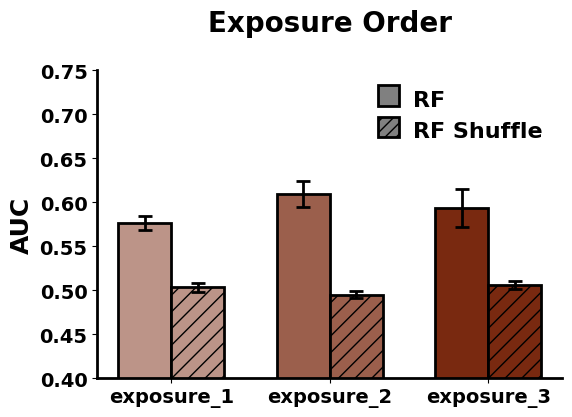

In [24]:
plot_multiple_decoders(order_results, title = "Exposure Order", color_list =exp_colors, start = 0 , stop = 3, legend_titles = ['exposure_1', 'exposure_2', 'exposure_3'], figsize = (6,4))

In [25]:
#X[n,t,s,d]

#currently PCA = [n, t*event] instead we could do [n, t, e] is the most basic which will not need any new labels. 
#we could add location for example [n, t, e, l]
def plot_explained_variance(explained_variance, n_components=10):
    import numpy as np
    import matplotlib.pyplot as plt

    # --- your explained variance dict looks something like this ---
    # explained_variance = {
    #     't':  [0.38, 0.11, 0.04, 0.02, ...],   # time
    #     'e':  [0.03, 0.01, 0.005, ...],          # event/stimulus
    #     'te': [0.09, 0.05, 0.02, ...],           # mixed interaction
    # }

    n_components = 10  # first 10 PCs to plot

    color_map = {
        't':  'mediumseagreen',   # time → green
        'e':  'steelblue',        # event → blue
        'te': 'darkgrey',         # mixed → grey
    }

    label_map = {
        't':  'Time',
        'e':  'Event',
        'te': 'Time × Event (mixed)',
    }

    # truncate or pad each list to n_components
    def get_values(lst, n):
        arr = np.array(lst[:n])          # take first n
        if len(arr) < n:                 # pad with zeros if shorter
            arr = np.pad(arr, (0, n - len(arr)))
        return arr

    x = np.arange(n_components)
    bar_width = 0.6

    fig, ax = plt.subplots(figsize=(10, 5))

    # plot order matters for stacking — draw bottom layers first
    # t at the base, then e on top, then te on top of that
    keys_ordered = ['t', 'e', 'te']
    bottoms = np.zeros(n_components)

    bars = {}
    for key in keys_ordered:
        if key not in explained_variance:
            continue
        vals = get_values(explained_variance[key], n_components)
        bars[key] = ax.bar(
            x,
            vals,
            bottom=bottoms,
            width=bar_width,
            color=color_map[key],
            label=label_map[key],
            edgecolor='white',
            linewidth=0.5,
        )
        bottoms += vals

    # formatting
    ax.set_xlabel('Component index', fontsize=12)
    ax.set_ylabel('Variance explained', fontsize=12)
    ax.set_title('dPCA — Variance Explained per Component', fontsize=13)
    ax.set_xticks(x)
    ax.set_xticklabels([f'PC{i+1}' for i in range(n_components)], fontsize=9)
    ax.legend(loc='upper right', framealpha=0.9)
    ax.set_ylim(0, max(bottoms) * 1.15)   # 15% headroom above tallest bar
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.2f}'))

    # optional: add total variance label on top of each bar
    for i, total in enumerate(bottoms):
        ax.text(i, total + max(bottoms) * 0.01, f'{total:.3f}',
                ha='center', va='bottom', fontsize=7, color='dimgrey')

    plt.tight_layout()
    plt.show()

Excluding 22_NCF_merged.rec with 1 neurons
Excluding 23_CNF_merged.rec with 3 neurons
Excluding 23_NFC_merged.rec with 2 neurons


c:\Users\megha\anaconda3\envs\ephys_env\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


Excluding 22_NCF_merged.rec with 1 neurons
Excluding 23_CNF_merged.rec with 3 neurons
Excluding 23_NFC_merged.rec with 2 neurons


c:\Users\megha\anaconda3\envs\ephys_env\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


Excluding 22_NCF_merged.rec with 1 neurons
Excluding 23_CNF_merged.rec with 3 neurons
Excluding 23_NFC_merged.rec with 2 neurons


c:\Users\megha\anaconda3\envs\ephys_env\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


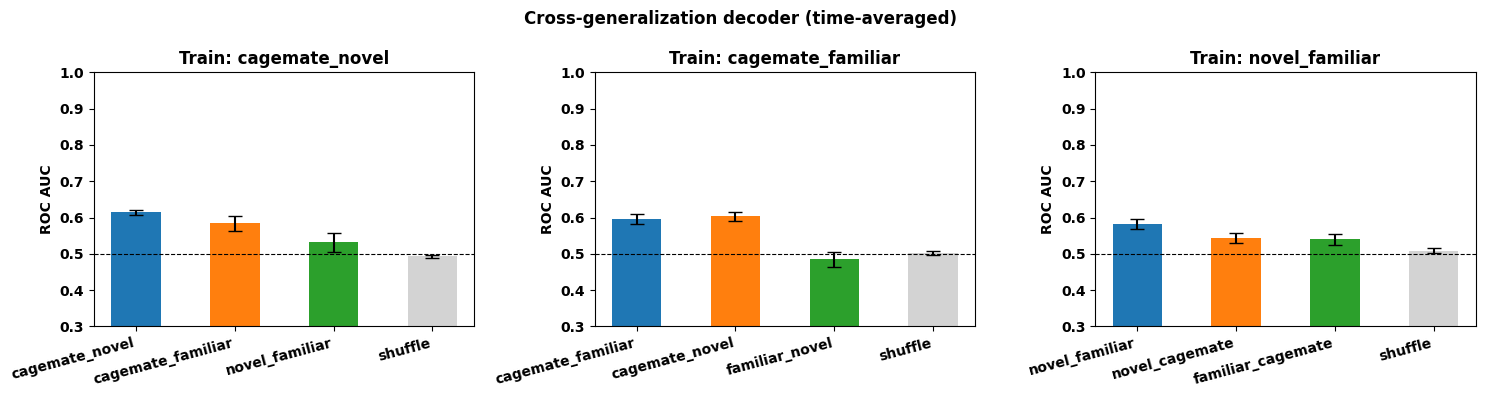

In [31]:
from importlib import reload
reload(decoders)
pre_window = 3
event_length = 5
num_folds = 5
min_neurons = 5
events = ['cagemate','novel','familiar']

agent_decoder_results_CCGP = decoders.trial_decoder_cross_generalization(only_subjects_spike,
                                         num_fold=num_folds,
                                         events =events,
                                         event_length = event_length,
                                         pre_window = pre_window,
                                         min_neurons = 5,
                                         classifier_type = 'linear')   
agent_decoder_results_CCGP.plot_average(start=0, stop =3)

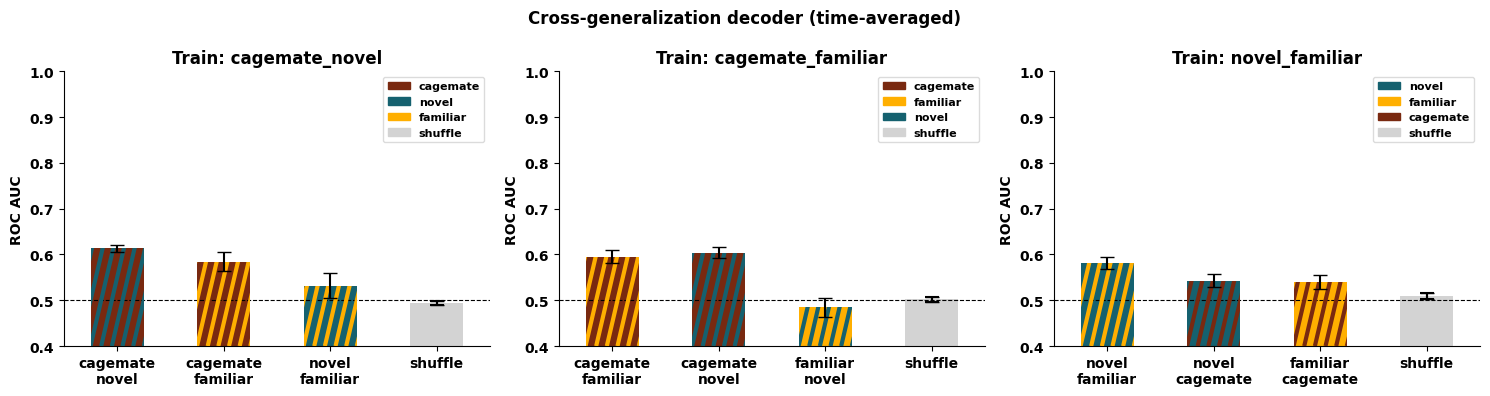

In [32]:
def plot_average(ccgp_results, color_dict, start=0, stop=None):
    """Bar plot of ROC AUC averaged over a time window.

    One subplot per training pair (3 total), three bars each — the trained pair
    (in-distribution) and the two generalization test cases. Bars are striped
    with the two colors of the tested pair. Shuffle bar is grey.

    Args:
        color_dict : dict mapping condition names to hex colors
                     e.g. {"cagemate": "#792910", "novel": "#15616F", "familiar": "#FFAF00"}
        start      : float, seconds from event onset to start averaging (default 0)
        stop       : float, seconds from event onset to stop averaging (default event_length)
    """

    def get_pair_colors(test_key, color_dict):
        for sep in [" vs ", "_vs_", " - ", "-", "_"]:
            if sep in test_key:
                parts = [p.strip() for p in test_key.split(sep, 1)]
                if len(parts) == 2:
                    return (color_dict.get(parts[0], "#888888"),
                            color_dict.get(parts[1], "#CCCCCC"))
        c = color_dict.get(test_key, "#888888")
        return c, "#CCCCCC"

    def striped_bar(ax, x, height, width, color1, color2,
                stripe_spacing=0.1, stripe_lw=3, yerr=None, capsize=5, y_min=0.4):
        import matplotlib.patches as patches

        ax.bar(x, height, width, color=color1, zorder=2)

        bar_left   = x - width / 2
        bar_height = height - y_min

        clip_rect = patches.Rectangle(
            (bar_left, y_min), width, bar_height,
            transform=ax.transData
        )
        ax.add_patch(clip_rect)
        clip_rect.set_visible(False)

        diag_extent = max(bar_height, width)
        xs = np.arange(bar_left - diag_extent, bar_left + width + diag_extent, stripe_spacing)
        for x_start in xs:
            line, = ax.plot(
                [x_start,              x_start + diag_extent],
                [y_min,                y_min + diag_extent],
                color=color2, lw=stripe_lw, zorder=3, solid_capstyle='butt'
            )
            line.set_clip_path(clip_rect)

        if yerr is not None:
            ax.errorbar(x, height, yerr=yerr,
                        fmt="none", color="black",
                        capsize=capsize, linewidth=1.5, zorder=5)

    train_keys = list(ccgp_results.roc_auc_scores.keys())
    fig, axes  = plt.subplots(1, len(train_keys),
                               figsize=(5 * len(train_keys), 4),
                               sharey=True)
    if len(train_keys) == 1:
        axes = [axes]

    for ax, train_key in zip(axes, train_keys):
        test_pairs  = ccgp_results.roc_auc_scores[train_key]
        test_keys   = list(test_pairs.keys())

        shuffle_key  = f"{train_key}_shuffle"
        display_keys = [k for k in test_keys if k != shuffle_key]
        ordered_keys = display_keys + ([shuffle_key] if shuffle_key in test_pairs else [])
        bar_labels   = display_keys + (["shuffle"]   if shuffle_key in test_pairs else [])

        means, errors = [], []
        for test_key in ordered_keys:
            nmr = test_pairs[test_key]
            x_time = np.linspace(
                -ccgp_results.pre_window,
                ccgp_results.event_length + ccgp_results.post_window,
                nmr.roc_auc.shape[0],
            )
            plot_start = np.where(x_time >= start)[0][0] if np.any(x_time >= start) else 0
            plot_stop  = (nmr.roc_auc.shape[0] if stop is None
                          else np.where(x_time <= stop)[0][-1] + 1)

            avg_per_fold = np.nanmean(nmr.roc_auc[plot_start:plot_stop], axis=0)
            means.append(np.nanmean(avg_per_fold))
            errors.append(sem(avg_per_fold, nan_policy="omit"))

        bar_width = 0.5
        for j, (test_key, mean, err, label) in enumerate(
                zip(ordered_keys, means, errors, bar_labels)):

            if test_key == shuffle_key:
                ax.bar(j, mean, bar_width, color="lightgray",
                       yerr=err, capsize=5,
                       error_kw={"elinewidth": 1.5, "capthick": 1.5},
                       zorder=2)
                ax.errorbar(j, mean, yerr=err, fmt="none", color="black",
                            capsize=5, linewidth=1.5, zorder=5)
            else:
                c1, c2 = get_pair_colors(test_key, color_dict)
                striped_bar(ax, j, mean, bar_width, c1, c2, yerr=err, y_min = 0.4)

        ax.set_xticks(range(len(ordered_keys)))
        ax.set_xticklabels([label.replace('_', '\n') for label in bar_labels], rotation=0)
        ax.axhline(0.5, color="k", linestyle="--", linewidth=0.8)
        ax.set_ylim(0.4, 1.0)
        ax.set_xlim(-0.5, len(ordered_keys) - 0.5)
        ax.tick_params(axis='y', labelleft=True)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.set_ylabel("ROC AUC")
        ax.set_title(f"Train: {train_key}")

        # legend
        seen, patches = set(), []
        for test_key in display_keys:
            c1, c2 = get_pair_colors(test_key, color_dict)
            for sep in [" vs ", "_vs_", " - ", "-", "_"]:
                if sep in test_key:
                    parts = [p.strip() for p in test_key.split(sep, 1)]
                    for part, c in zip(parts, [c1, c2]):
                        if part not in seen:
                            patches.append(mpatches.Patch(color=c, label=part))
                            seen.add(part)
                    break
        patches.append(mpatches.Patch(color="lightgray", label="shuffle"))
        ax.legend(handles=patches, fontsize=8, loc="upper right", framealpha=0.7)

    fig.suptitle("Cross-generalization decoder (time-averaged)")
    plt.tight_layout()
    plt.show()

color_dict = {
    "cagemate": "#792910",
    "novel":    "#15616F",
    "familiar": "#FFAF00"
}
plot_average(agent_decoder_results_CCGP, color_dict=color_dict, start = 0 , stop=3)

In [33]:
def test_vs_shuffle(ccgp_result, start=0, stop=None):
    """One-tailed t-test: is each real condition's ROC AUC > shuffle?

    For each training key, tests each non-shuffle test condition against
    the shuffle control using a paired one-tailed t-test across folds.

    Args:
        start : float, seconds from event onset to start averaging (default 0)
        stop  : float, seconds from event onset to stop averaging (default event_length)

    Returns:
        results : dict of {train_key: {test_key: {'t': t, 'p': p, 'sig': bool}}}
    """
    from scipy.stats import ttest_rel

    results = {}

    for train_key in ccgp_result.roc_auc_scores:
        test_pairs  = ccgp_result.roc_auc_scores[train_key]
        shuffle_key = f"{train_key}_shuffle"
        results[train_key] = {}

        if shuffle_key not in test_pairs:
            print(f"No shuffle found for {train_key}, skipping.")
            continue

        # get per-fold averages for shuffle
        nmr_shuf = test_pairs[shuffle_key]
        x_time   = np.linspace(
            -ccgp_result.pre_window,
            ccgp_result.event_length + ccgp_result.post_window,
            nmr_shuf.roc_auc.shape[0],
        )
        plot_start = np.where(x_time >= start)[0][0] if np.any(x_time >= start) else 0
        plot_stop  = (nmr_shuf.roc_auc.shape[0] if stop is None
                      else np.where(x_time <= stop)[0][-1] + 1)

        shuf_per_fold = np.nanmean(nmr_shuf.roc_auc[plot_start:plot_stop], axis=0)

        for test_key in test_pairs:
            if test_key == shuffle_key:
                continue

            nmr = test_pairs[test_key]
            real_per_fold = np.nanmean(nmr.roc_auc[plot_start:plot_stop], axis=0)

            # one-tailed: test whether real > shuffle
            t, p_two = ttest_rel(real_per_fold, shuf_per_fold)
            p_one    = p_two / 2 if t > 0 else 1.0 - p_two / 2

            results[train_key][test_key] = {
                't':   t,
                'p':   p_one,
                'sig': p_one < 0.05
            }
            print(f"{train_key} | {test_key}: t={t:.3f}, p={p_one:.4f}"
                  f"{'  *' if p_one < 0.05 else ''}"
                  f"{'*' if p_one < 0.01 else ''}"
                  f"{'*' if p_one < 0.001 else ''}")

    return results
stats_results = test_vs_shuffle(agent_decoder_results_CCGP, start=0, stop=3)

cagemate_novel | cagemate_novel: t=19.595, p=0.0000  ***
cagemate_novel | cagemate_familiar: t=3.783, p=0.0097  **
cagemate_novel | novel_familiar: t=1.633, p=0.0889
cagemate_familiar | cagemate_familiar: t=9.072, p=0.0004  ***
cagemate_familiar | cagemate_novel: t=7.944, p=0.0007  ***
cagemate_familiar | familiar_novel: t=-0.966, p=0.8056
novel_familiar | novel_familiar: t=4.034, p=0.0078  **
novel_familiar | novel_cagemate: t=2.072, p=0.0535
novel_familiar | familiar_cagemate: t=1.748, p=0.0777


In [34]:
def test_pairwise_conditions(ccgp_result, start=0, stop=None):
    """Pairwise two-tailed t-tests across real test conditions, with global Holm correction.

    For each training key, compares ROC AUC between every pair of non-shuffle
    test conditions across folds. Global Holm-Bonferroni correction applied
    across all pairwise comparisons.

    Args:
        ccgp_result : CCGP result object
        start       : float, seconds from event onset to start averaging (default 0)
        stop        : float, seconds from event onset to stop averaging (default event_length)

    Returns:
        results : dict of {train_key: {(test_key_a, test_key_b): {'t', 'p_raw', 'p_corr', 'sig'}}}
    """
    from scipy.stats import ttest_rel
    from statsmodels.stats.multitest import multipletests
    from itertools import combinations

    # ── pass 1: collect per-fold averages for all real conditions ─────────────
    fold_avgs = {}   # {train_key: {test_key: array of shape (n_folds,)}}

    for train_key in ccgp_result.roc_auc_scores:
        test_pairs  = ccgp_result.roc_auc_scores[train_key]
        shuffle_key = f"{train_key}_shuffle"
        fold_avgs[train_key] = {}

        # build time axis once per train key
        first_key = next(iter(test_pairs))
        x_time    = np.linspace(
            -ccgp_result.pre_window,
            ccgp_result.event_length + ccgp_result.post_window,
            test_pairs[first_key].roc_auc.shape[0],
        )
        plot_start = np.where(x_time >= start)[0][0] if np.any(x_time >= start) else 0
        plot_stop  = (test_pairs[first_key].roc_auc.shape[0] if stop is None
                      else np.where(x_time <= stop)[0][-1] + 1)

        for test_key, nmr in test_pairs.items():
            if test_key == shuffle_key:
                continue
            fold_avgs[train_key][test_key] = np.nanmean(
                nmr.roc_auc[plot_start:plot_stop], axis=0
            )

    # ── pass 2: collect all pairwise t-tests ──────────────────────────────────
    records = []   # (train_key, key_a, key_b, t, p_raw)

    for train_key, conditions in fold_avgs.items():
        keys = list(conditions.keys())
        for key_a, key_b in combinations(keys, 2):
            t, p = ttest_rel(conditions[key_a], conditions[key_b])
            records.append((train_key, key_a, key_b, t, p))

    if not records:
        print("No pairwise comparisons to run.")
        return {}

    # ── pass 3: global Holm correction ────────────────────────────────────────
    p_raw              = np.array([r[4] for r in records])
    reject, p_corr, _, _ = multipletests(p_raw, alpha=0.05, method='holm')

    # ── pass 4: assemble and print ────────────────────────────────────────────
    results = {}

    def stars(p):
        if p < 0.001: return "***"
        if p < 0.01:  return "**"
        if p < 0.05:  return "*"
        return "n.s."

    print(f"\n{'Train':<25} {'Condition A':<25} {'Condition B':<25}"
          f" {'t':>7} {'p_raw':>8} {'p_holm':>8}  sig")
    print("-" * 100)

    for (train_key, key_a, key_b, t, p), p_adj, rej in zip(records, p_corr, reject):
        if train_key not in results:
            results[train_key] = {}

        results[train_key][(key_a, key_b)] = {
            't':      t,
            'p_raw':  p,
            'p_corr': p_adj,
            'sig':    rej
        }

        print(f"{train_key:<25} {key_a:<25} {key_b:<25}"
              f" {t:>7.3f} {p:>8.4f} {p_adj:>8.4f}  {stars(p_adj)}")

    return results
pairwise_stats = test_pairwise_conditions(agent_decoder_results_CCGP, start=0, stop=3)


Train                     Condition A               Condition B                     t    p_raw   p_holm  sig
----------------------------------------------------------------------------------------------------
cagemate_novel            cagemate_novel            cagemate_familiar           1.196   0.2977   1.0000  n.s.
cagemate_novel            cagemate_novel            novel_familiar              3.671   0.0214   0.1495  n.s.
cagemate_novel            cagemate_familiar         novel_familiar              1.111   0.3290   1.0000  n.s.
cagemate_familiar         cagemate_familiar         cagemate_novel             -0.408   0.7044   1.0000  n.s.
cagemate_familiar         cagemate_familiar         familiar_novel              9.479   0.0007   0.0062  **
cagemate_familiar         cagemate_novel            familiar_novel              3.957   0.0167   0.1338  n.s.
novel_familiar            novel_familiar            novel_cagemate              3.042   0.0383   0.2301  n.s.
novel_familiar       

# dPCA

All set to analyze


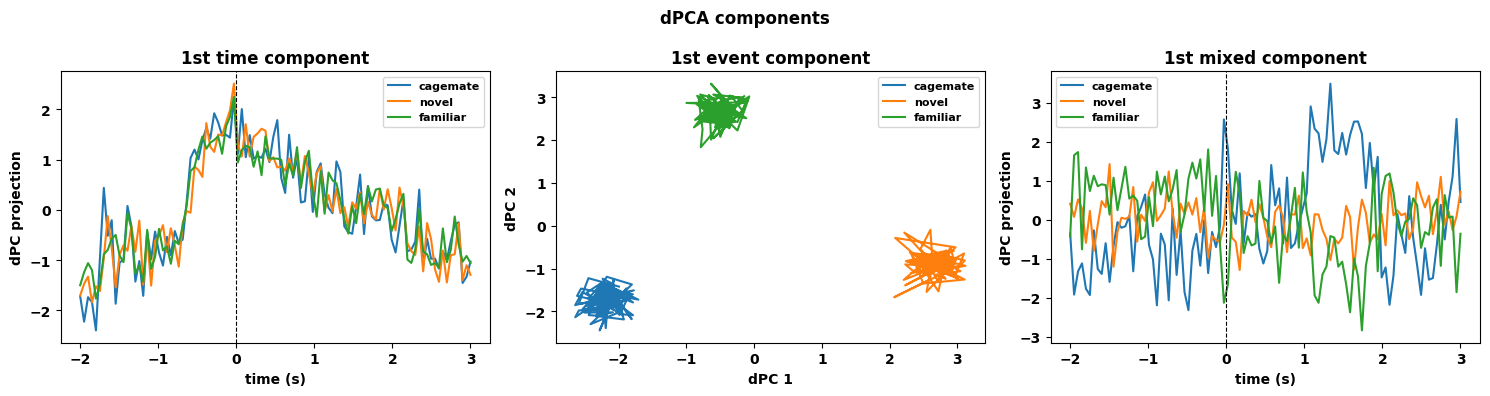

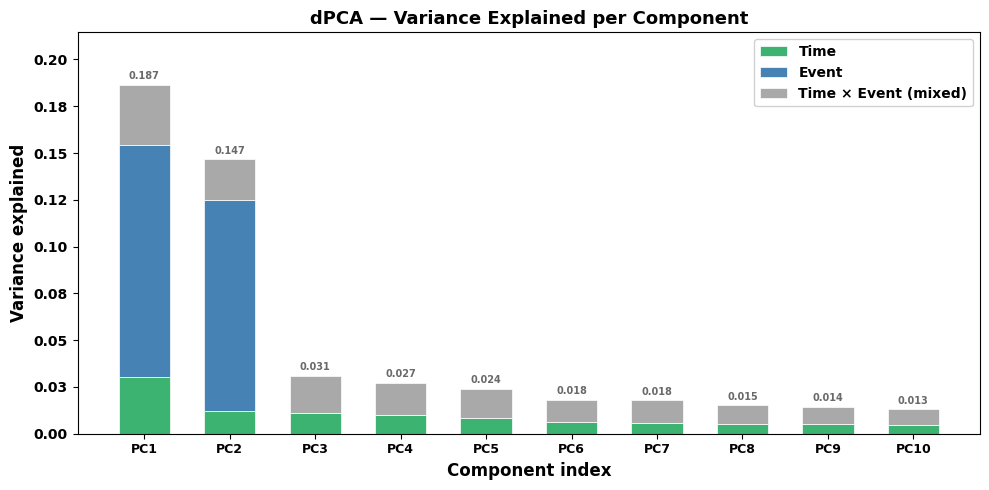

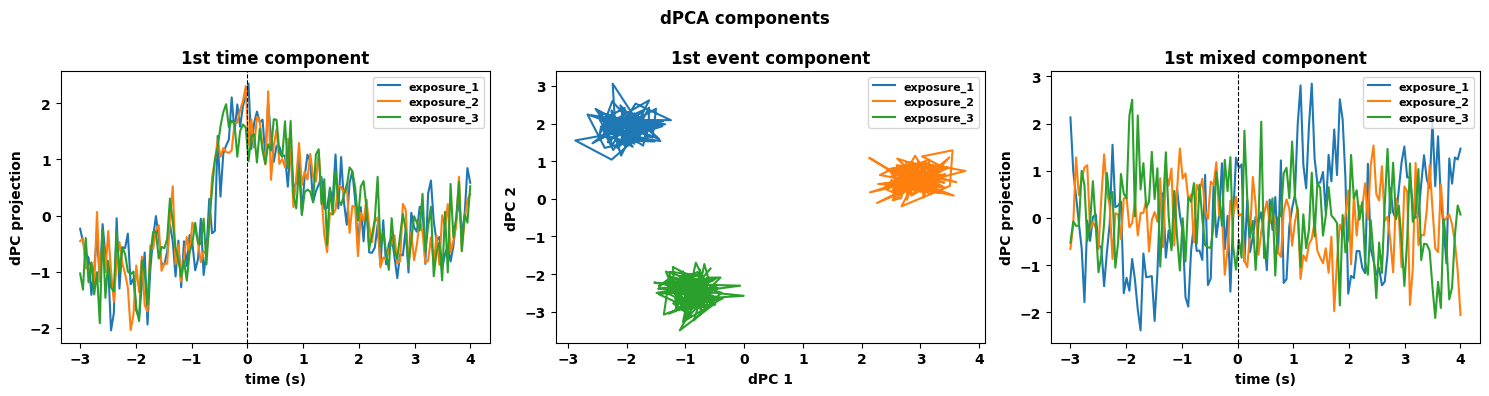

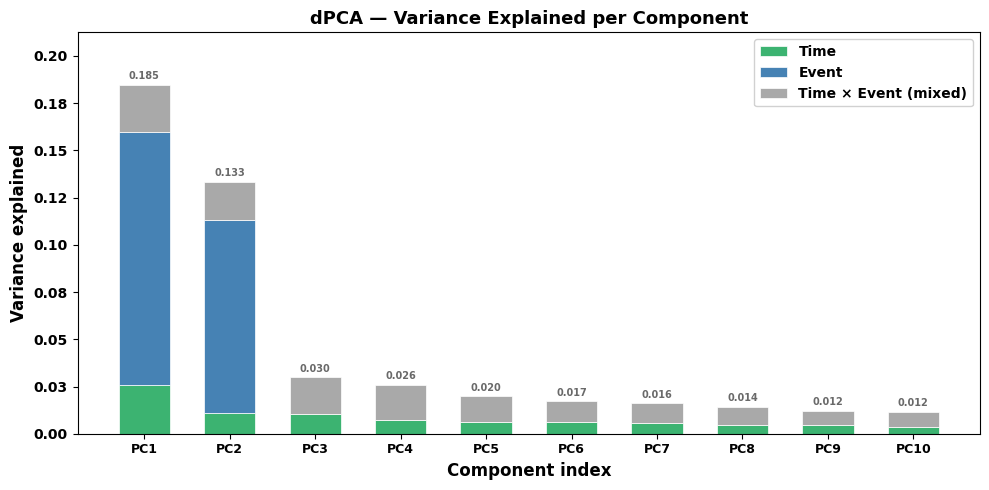

In [ ]:
only_subjects_spike.analyze(smoothing_window =None, timebin = 50, ignore_freq = 0.5)
events = ['cagemate', 'novel', 'familiar']
dpcaresults= pcat.run_dpca(only_subjects_spike,  3, 2, events = events, plot = True)
plot_explained_variance(dpcaresults.explained_variance, n_components=10)
events = ['cagemate', 'novel', 'familiar']
dpcaresults= pcat.run_dpca(only_subjects_spike,  4, 3, events = ['exposure_1', 'exposure_2', 'exposure_3'], plot = True)
plot_explained_variance(dpcaresults.explained_variance, n_components=10)

# RSA 

Skipping 22_NCF_merged.rec: 1 neurons < min_neurons=5
Skipping 23_CNF_merged.rec: 3 neurons < min_neurons=5
Skipping 23_NFC_merged.rec: 1 neurons < min_neurons=5
Skipping 22_NCF_merged.rec: 1 neurons < min_neurons=5
Skipping 23_CNF_merged.rec: 3 neurons < min_neurons=5
Skipping 23_NFC_merged.rec: 1 neurons < min_neurons=5
Skipping 22_NCF_merged.rec: 1 neurons < min_neurons=5
Skipping 23_CNF_merged.rec: 3 neurons < min_neurons=5
Skipping 23_NFC_merged.rec: 1 neurons < min_neurons=5


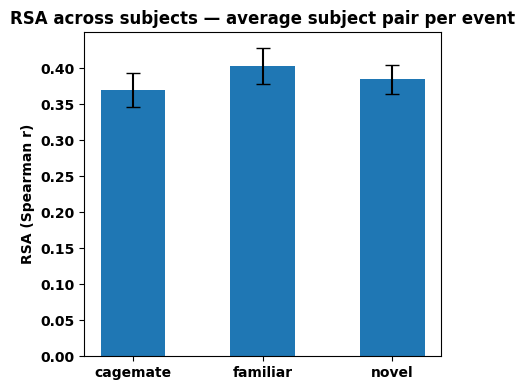

Skipping 22_NCF_merged.rec: 1 neurons < min_neurons=5
Skipping 23_CNF_merged.rec: 3 neurons < min_neurons=5
Skipping 23_NFC_merged.rec: 1 neurons < min_neurons=5


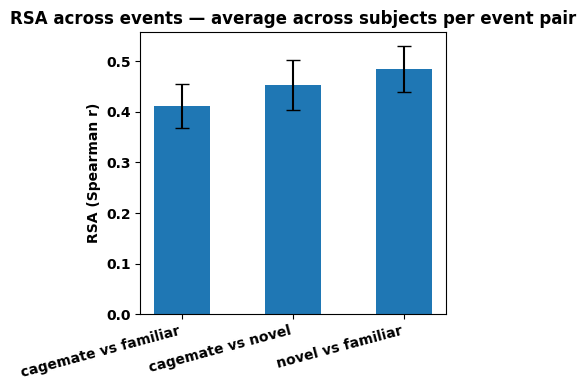

Skipping 22_NCF_merged.rec: 1 neurons < min_neurons=5
Skipping 23_CNF_merged.rec: 3 neurons < min_neurons=5
Skipping 23_NFC_merged.rec: 1 neurons < min_neurons=5


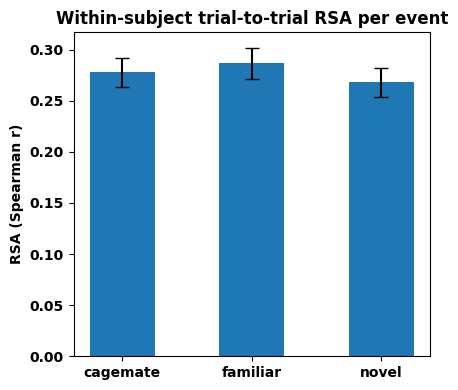

In [36]:
from importlib import reload
across_subjects_rsa_results = pcat.rsa(only_subjects_spike, events, 3, 1, across_subjects = True, plot = True, min_neurons = 5)
across_events_rsa_results = pcat.rsa(only_subjects_spike, events, 3, 1, across_events = True, plot = True, min_neurons = 5)
across_trials_rsa_results = pcat.rsa(only_subjects_spike, events, 3, 1, plot = True, min_neurons = 5)